# Purpose 
Teaches 
What is PCA         
Inution ,geometric meaning ,mathmatics of it         
How to apply PCA on real world Dataset iris 
 Example PCA and visualise the the 4d dim data to 3d or 2d.      
Use the Iris dataset

- import libraries and data
- train test split 
- see problem we apply scatter plot of all columns 
- before pca classifer algo (knn) and check accuracy
- after pca classifer algo (knn) and check accuracy
- visualise in 2d and 3d 
- Question : visualisation kesa kara training data ya testing data par ya pura data par.

# What is PCA
PCA is unsupervisied machine learning algorithum .      
it uses in dimensional reduction
Example in iris dataset we have 4 columns we humans only visualise in 1d,2d,3d we can can not visualise beyound 3d , 4d or higher dimension data pca gives us power that we visualise our data .


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

In [34]:
X = load_iris(as_frame=True)['data'] # feature
y = load_iris(as_frame=True)['target'] # target

In [35]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [36]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int32

# train test split

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.2,
                                                    random_state=2
                                                    )

In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


# Apply knn 

In [40]:
knn = KNeighborsClassifier()

# fit model
knn.fit(X_train,y_train)

y_pred = knn.predict(X_test)


accuracy_score(y_test,y_pred)

0.9666666666666667

# Apply PCA

In [41]:
pca = PCA(n_components=2)

X_train_pca= pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


print(X_train_pca.shape)
print(X_test_pca.shape)

(120, 2)
(30, 2)


In [42]:
knn = KNeighborsClassifier()

# fit model
knn.fit(X_train_pca,y_train)

y_pred = knn.predict(X_test_pca)


accuracy_score(y_test,y_pred)

0.9

In [ ]:
# Eigenvalues
pca.explained_variance_

array([2.92404704, 0.93113765])

In [ ]:
# how much percentage of varience explained by each principle Components
pca.explained_variance_ratio_

array([0.72492   , 0.23084454])

In [ ]:
# Eigen Vectors 
pca.components_

array([[ 0.51374259, -0.27737345,  0.58209532,  0.56594837],
       [ 0.40993653,  0.91002892,  0.01332458,  0.06018188]])

In [47]:
principle_components = pca.components_
principle_components

array([[ 0.51374259, -0.27737345,  0.58209532,  0.56594837],
       [ 0.40993653,  0.91002892,  0.01332458,  0.06018188]])

In [53]:
df = pd.merge(
    left = X,
    right= y,
    how = 'inner',
    left_index=True,
    right_index=True
)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [56]:
df.iloc[:,0:2]

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6
...,...,...
145,6.7,3.0
146,6.3,2.5
147,6.5,3.0
148,6.2,3.4


In [ ]:
np.dot(df.iloc)

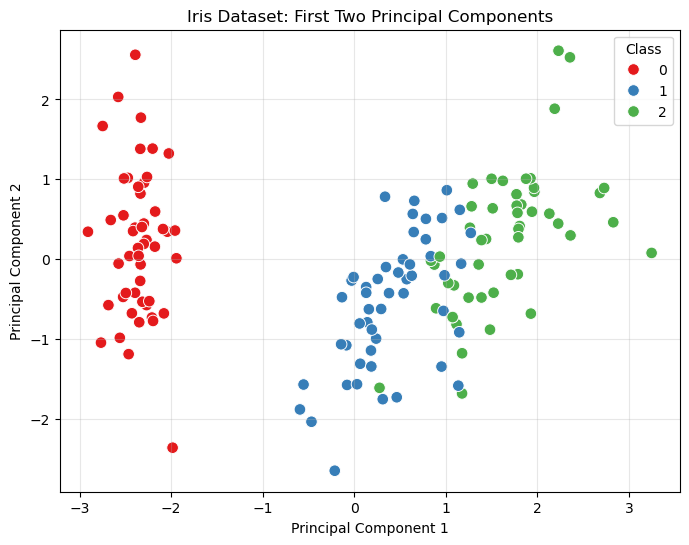

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine train and test PCA data for visualization
X_pca_all = np.vstack((X_train_pca, X_test_pca))
y_all = np.hstack((y_train, y_test))

# Put into a DataFrame for easy plotting
pca_df = pd.DataFrame({
    'PC1': X_pca_all[:, 0],
    'PC2': X_pca_all[:, 1],
    'target': y_all
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='target',
    palette='Set1',
    s=70
)
plt.title('Iris Dataset: First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Class')
plt.grid(alpha=0.3)
plt.show()

In [58]:
X_pca_all

array([[ 1.08908007e+00, -3.27566109e-01],
       [-1.94328124e+00,  1.15488219e-02],
       [-1.34381195e-01, -4.75806360e-01],
       [ 2.35588396e+00,  2.52657275e+00],
       [ 1.29418622e-01, -3.49216492e-01],
       [-2.33079079e+00,  1.77163948e+00],
       [ 1.78663910e+00, -1.88051959e-01],
       [ 5.31361781e-01, -2.21388738e-03],
       [ 3.10953643e-01, -1.75229136e+00],
       [ 1.82433754e+00,  6.83670982e-01],
       [ 5.72405047e-01, -2.50378868e-01],
       [ 4.80995238e-01, -1.66769178e-01],
       [ 1.96684710e+00,  8.44028092e-01],
       [-4.67752720e-01, -2.03483101e+00],
       [-2.45629103e+00,  3.96615000e-02],
       [ 1.11653736e+00, -8.13832511e-01],
       [-2.26967790e+00,  2.40567059e-01],
       [ 7.82397437e-01,  5.04736702e-01],
       [-2.39553373e+00,  3.94781094e-01],
       [-2.29856193e+00,  4.46159310e-01],
       [-2.17537492e+00,  5.96454537e-01],
       [ 2.75607276e-01, -1.61031478e+00],
       [ 1.29370260e+00,  9.46175412e-01],
       [ 2.

In [59]:
y_all

array([2, 0, 1, 2, 1, 0, 2, 1, 1, 2, 1, 1, 2, 1, 0, 2, 0, 1, 0, 0, 0, 2,
       2, 2, 0, 2, 2, 2, 2, 0, 0, 2, 1, 1, 2, 2, 1, 0, 1, 0, 2, 1, 1, 0,
       1, 1, 1, 2, 0, 1, 0, 1, 2, 0, 1, 0, 0, 0, 2, 2, 0, 0, 2, 2, 1, 2,
       1, 1, 2, 0, 2, 2, 2, 0, 2, 0, 0, 1, 2, 1, 2, 1, 1, 2, 1, 1, 1, 2,
       1, 2, 1, 0, 1, 1, 1, 1, 2, 1, 0, 0, 2, 1, 2, 0, 2, 0, 2, 2, 0, 1,
       0, 2, 1, 0, 2, 1, 0, 0, 1, 0, 0, 0, 2, 0, 0, 2, 0, 2, 2, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 2, 1, 1, 1, 2, 1, 1, 0, 0, 2, 0, 2])

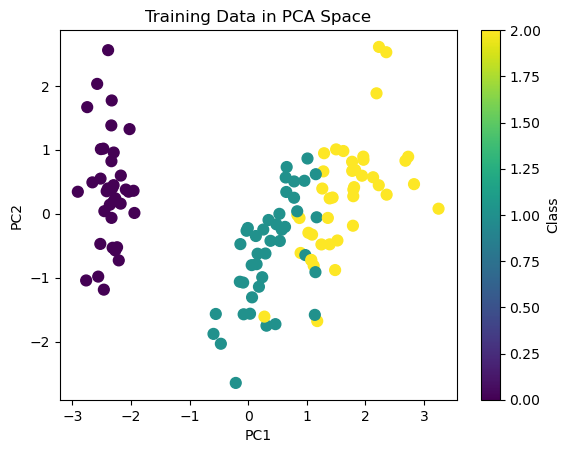

In [60]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', s=60)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Training Data in PCA Space')
plt.colorbar(label='Class')
plt.show()

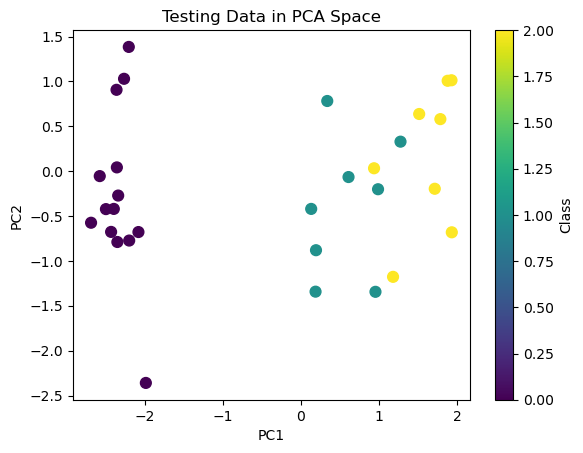

In [61]:
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='viridis', s=60)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Testing Data in PCA Space')
plt.colorbar(label='Class')
plt.show()

In [63]:
y_train

126    2
23     0
64     1
117    2
84     1
      ..
75     1
43     0
22     0
72     1
15     0
Name: target, Length: 120, dtype: int32

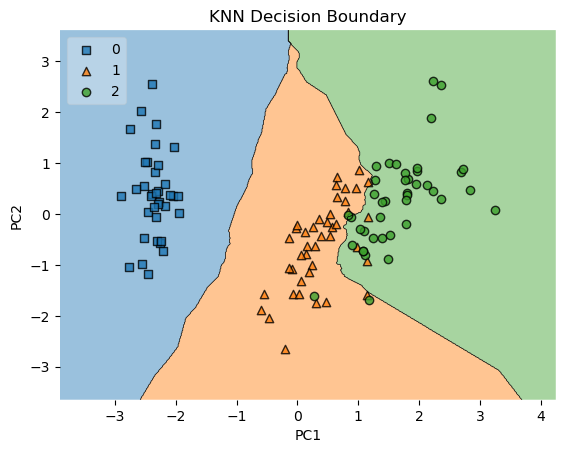

In [64]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# X_train_pca must have only 2 columns
knn = KNeighborsClassifier()
knn.fit(X_train_pca, y_train)

plot_decision_regions(X_train_pca,y_train.to_numpy() , clf=knn, legend=2)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KNN Decision Boundary")
plt.show()

In [15]:
import plotly.express as px

df = px.data.iris()
features = ["sepal_width", "sepal_length", "petal_width", "petal_length"]

fig = px.scatter_matrix(
    df,
    dimensions=features,
    color="species",
    height=600,
    #width=900
)
fig.update_traces(diagonal_visible=False)
fig.show()

In [17]:
import plotly.express as px
from sklearn.decomposition import PCA

df = px.data.iris()
features = ["sepal_width", "sepal_length", "petal_width", "petal_length"]

pca = PCA()
components = pca.fit_transform(df[features])
labels = {
    str(i): f"PC {i+1} ({var:.1f}%)"
    for i, var in enumerate(pca.explained_variance_ratio_ * 100)
}

fig = px.scatter_matrix(
    components,
    labels=labels,
    dimensions=range(4),
    color=df["species"],
    height=600
)
fig.update_traces(diagonal_visible=False)
fig.show()

In [26]:
import plotly.express as px
from sklearn.decomposition import PCA

df = px.data.iris()
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

pca = PCA(n_components=2)
components = pca.fit_transform(X)

fig = px.scatter(components, x=0, y=1, color=df['species'],height=600)
fig.show()

In [27]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [30]:
import pandas as pd
pd.DataFrame(pca.fit_transform(X))

,0,1
0,-2.684207,0.326607
1,-2.715391,-0.169557
2,-2.889820,-0.137346
3,-2.746437,-0.311124
4,-2.728593,0.333925
...,...,...
145,1.944017,0.187415
146,1.525664,-0.375021
147,1.764046,0.078519
148,1.901629,0.115877


In [23]:
import plotly.express as px
from sklearn.decomposition import PCA

df = px.data.iris()
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

pca = PCA(n_components=3)
components = pca.fit_transform(X)

total_var = pca.explained_variance_ratio_.sum() * 100

fig = px.scatter_3d(
    components, x=0, y=1, z=2, color=df['species'],
    title=f'Total Explained Variance: {total_var:.2f}%',
    labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3'},
    height=800,
    width=800
)
fig.show()